# ‎ ‎ ‎ ‎ ‎‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎ ‎  Project Name : Sales Lead Quality effectivenes/ Prediction
---

**Member Name** :  **Mohd Huzaif(Individual)**   

---

# **Column Description:-**


| Column Name       | Description                                                                                                                                                  |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Created**       | Date and time when the sales record or lead was created in the system. Used for time-based analysis such as daily, weekly, or monthly sales trends.          |
| **Product_ID**    | Unique identifier of the product associated with the sale or lead. Helps in tracking product-wise performance and revenue contribution.                      |
| **Source**        | Channel from which the lead or sale originated (e.g., Website, Referral, Advertisement, Walk-in). Useful for marketing and source effectiveness analysis.    |
| **Mobile**        | Customer’s mobile phone number provided at the time of lead or order creation. Mainly used for customer contact and duplicate detection (not for modeling).  |
| **EMAIL**         | Customer’s email address associated with the sale or lead. Can be used for customer identification, communication, and duplicate record checks.              |
| **Sales_Agent**   | Name or ID of the sales representative handling the lead or sale. Used to evaluate agent-wise performance and conversion rates.                              |
| **Location**      | Geographic location of the customer (city/region). Helps in regional sales analysis and demand forecasting.                                                  |
| **Delivery_Mode** | Mode through which the product is delivered to the customer (e.g., Home Delivery, Pickup, Online Fulfillment). Useful for logistics and operations analysis. |
| **Status**        | Current state of the sale or lead (e.g., Pending, Converted, Cancelled, Delivered). Often used as the **target variable** in conversion or churn analysis.   |


---
------

**`I go step by step  Here's the structure we follow during project :`**
 
  **`Task :- 1. Data exploration insights – Sales effectiveness.
`**

1. `Import All type of Library we required for Data Analysis & machine learning Model creation`

2. `Load  data`

3. `Data Inspection`

4. `Data cleaning`

5. `Univariate Analysis`

6. `Bivariate & Multivariate Analysis`

7. `Submit Detailed Data Analysis Report(Task -1 completed)`

8. `2. ML model to predict the Lead Category (High Potential , Low
Potential).`

----
---

## 1.Import All type of Library we required for Data Analysis & machine learning Model creation

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import mysql.connector# module for mysql connnection 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier #  ( tree based model ) 
from sklearn.ensemble import RandomForestClassifier # Bootstrap Aggregation ) 
from xgboost import XGBClassifier  # ( Boosting )
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,f1_score 
import joblib
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'mysql'

## 2. Load  data  
* *Load data from mysql Internal Connector*

In [2]:
# Create MySQL connection
conn = mysql.connector.connect(
    host="18.136.157.135",
    port=3306,
    user="dm_team2",
    password="DM!$Team&27@9!20!",
    database="project_sales"
)

# SQL query
query = "SELECT * FROM data"

# Load data into Pandas DataFrame
df = pd.read_sql(query, conn)

# Close connection
conn.close()

In [3]:
# View data
print(df.head())

            Created Product_ID   Source      Mobile               EMAIL  \
0  14-11-2018 10:05             Website  984XXXXXXX  aXXXXXXX@gmail.com   
1  14-11-2018 09:22             Website     XXXXXXX             #VALUE!   
2  14-11-2018 09:21             Website     XXXXXXX  dXXXXXXX@yahoo.com   
3  14-11-2018 08:46             Website     XXXXXXX  wXXXXXXX@gmail.com   
4  14-11-2018 07:34             Website     XXXXXXX  cXXXXXXX@gmail.com   

      Sales_Agent Location Delivery_Mode Status  
0  Sales-Agent-11                 Mode-5   Open  
1  Sales-Agent-10                 Mode-5   Open  
2  Sales-Agent-10                 Mode-5   Open  
3  Sales-Agent-10                 Mode-5   Open  
4  Sales-Agent-10                 Mode-5   Open  


## 3. `Data Inspection`

In [4]:
# shape of Data
print(f'Total number of rows    : {df.shape[0]}')
print(f'Total number of columns : {df.shape[1]}')

Total number of rows    : 7422
Total number of columns : 9


In [5]:
df.describe()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7422,7422,7422,7422,7422,7422,7422,7422,7422
unique,6752,30,26,487,883,13,18,5,11
top,27-09-2018 11:00,18,Call,,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,1711,2547,1810,1701,1500,2500,2975,1536


In [6]:
print('List of column : ')
print(df.columns.tolist())

List of column : 
['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status']


In [7]:
print(f'Total no. of null values : {df.isnull().sum().sum()}')

Total no. of null values : 0


In [8]:
print(f'Total duplicated values : {df.duplicated().sum()}')


Total duplicated values : 2


In [9]:
# drop duplicate value  
df = df.drop_duplicates()

In [10]:
print(f'Total duplicated values : {df.duplicated().sum()}')

Total duplicated values : 0


---
### Summary 
* Total rows : 7422
* Total columns : 9
* List of column
   * 'Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status'
* Total null values : 0
* Total duplicated values :  2 , So I drop this.
---
* Dataset has 7420 rows
* No column shows NaN missing values
* But some values are actually missing or wrong:
* Mobile has many blank values
* EMAIL has many `VALUE!` entries
* Some values repeat many times:
* Product_ID `18` appears the most
* Source is mostly Call
* Status is mostly Junk Lead
* Few sales agents handle many leads
* `Other Locations` is used too often
* *Data is not clean, even though it looks complete*
---
---

## 4. `Data cleaning`
 * Cleaned data one by one column 

### Column name :   Created

In [11]:
df[df['Created'].astype(str).str.strip() == '']

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status


In [12]:
(df['Created'].astype(str).str.strip() == '').sum()

np.int64(0)

In [13]:
df['Created'] = pd.to_datetime(df['Created'], errors='coerce')

In [14]:
df['Created'].info()

<class 'pandas.core.series.Series'>
Index: 7420 entries, 0 to 7421
Series name: Created
Non-Null Count  Dtype         
--------------  -----         
7420 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 115.9 KB


---
#### Summary 
* firstly check any space `'  '` to convert into nan value . But not detect Aanything 
* Converted `created` column datatype `object to datetime`.
* 2 rows removed just because thier duplicates.
---
 

### `Column name :  Product_ID`

In [15]:
print(f"Total no. of missing record which contains only spaces : {(df['Product_ID'].astype(str).str.strip() == '').sum()}")

Total no. of missing record which contains only spaces : 56


In [16]:
print(f"Total percentage of missing record which contains only spaces : { round((df['Product_ID'].astype(str).str.strip() == '').sum()/len(df)*100, 2)}")

Total percentage of missing record which contains only spaces : 0.75


In [17]:
#convert blank into nan values 
df['Product_ID'] = df['Product_ID'].astype(str).str.strip()
df['Product_ID'].replace('', np.nan, inplace=True)
(df['Product_ID'].isna()).sum()
print("Now blank values converted into nan values which is python understandable form")

Now blank values converted into nan values which is python understandable form


In [18]:
df = df[df['Product_ID'].notna()]

In [19]:
print(f"Total percentage of  missing record which contains only spaces : {round((df['Product_ID'].astype(str).str.strip() == '').sum()/len(df)*100, 2)}")

Total percentage of  missing record which contains only spaces : 0.0


In [20]:
df['Product_ID'] = pd.to_numeric(df['Product_ID'], errors='coerce')


---
#### Summary : 
* Total no. of missing record which contains only spaces : 56
* Total percentage of missing record which contains only spaces : `0.75%`
* Best thing remove it because it less then 1%.
* `Since Product_ID is important and missing rate is < 1%:`
   *  Drop those rows
   *  Product_ID is an identifier
   *  Filling it would be fake data
   *  Removing 0.75% rows won’t affect model and data analysis process
---

* convert object datatype to numeric datatype

  **Note :  Now product_ID column is cleaned and ready to cleaned** 
---
---

### Column name : Source 
 `The Source column shows how a lead/customer came to the company.`  

In [21]:
print(f"Total percentage of missing slources which contains only spaces : {(df['Source'].astype(str).str.strip() == '').sum()}")

Total percentage of missing slources which contains only spaces : 7


In [22]:
print(f"Total percentage of missing slources which contains only spaces : {round((df['Source'].astype(str).str.strip() == '').sum()/len(df)*100,5)}")

Total percentage of missing slources which contains only spaces : 0.09506


In [23]:
print(f"total no. of unique source name : -  \n")
print(df['Source'].unique())

total no. of unique source name : -  

['Live Chat-Google Organic' 'Call' 'Website' 'Live Chat-Direct'
 'By Recommendation' 'Customer Referral' 'Live Chat-Blog' 'Live Chat -PPC'
 'Live Chat-Google Ads' 'Live Chat-Adwords Remarketing' 'E-Mail Message'
 'Existing Client' 'Live Chat-CPC' 'Existing Customer' 'Live Chat-Quora'
 'US Website' 'Just Dial' '' 'Campaign' 'Other' 'E-mail Campaign'
 'CRM form' 'SMS Campaign' 'Personal Contact' 'Live Chat-Youtube'
 'Live Chat-Justdial']


In [24]:
#convert to string and remove spaces 
df['Source'] = df['Source'].astype(str).str.strip()

In [25]:
#replace blank value with nan-value 
df['Source'].replace('',np.nan,inplace=True)

In [26]:
df['Source'] = df['Source'].str.replace(' -','-',regex=False)
df['Source'] = df['Source'].str.replace('- ','-',regex=False)

In [27]:
# 4. Standardize text format (case)
df['Source'] = df['Source'].str.title()

In [28]:
# 5. Merge same-meaning categories
df['Source'] = df['Source'].replace({
    'Existing Client': 'Existing Customer',
    'E-Mail Message': 'Email',
    'E-Mail Campaign': 'Email',
    'Just Dial': 'Justdial'
})


In [29]:
# 6. Group all Live Chat related sources
df['Source_Clean'] = df['Source'].apply(
    lambda x: 'Live Chat' if isinstance(x, str) and x.startswith('Live Chat') else x
)

In [30]:
df['Source'].nunique()

23

In [31]:
df['Source'].unique()

array(['Live Chat-Google Organic', 'Call', 'Website', 'Live Chat-Direct',
       'By Recommendation', 'Customer Referral', 'Live Chat-Blog',
       'Live Chat-Ppc', 'Live Chat-Google Ads',
       'Live Chat-Adwords Remarketing', 'Email', 'Existing Customer',
       'Live Chat-Cpc', 'Live Chat-Quora', 'Us Website', 'Justdial', nan,
       'Campaign', 'Other', 'Crm Form', 'Sms Campaign',
       'Personal Contact', 'Live Chat-Youtube', 'Live Chat-Justdial'],
      dtype=object)

In [32]:
# Convert to title case
df['Source'] = df['Source'].str.title()

In [33]:
df['Source'] = df['Source'].str.replace('Ppc', 'PPC', regex=False)
df['Source'] = df['Source'].str.replace('Cpc', 'CPC', regex=False)
df['Source'] = df['Source'].str.replace('Crm', 'CRM', regex=False)
df['Source'] = df['Source'].str.replace('Us Website', 'US Website', regex=False)

In [34]:
df['Source'] = df['Source'].replace({
    'Customer Referral': 'Referral',
    'By Recommendation': 'Referral'})

In [35]:
df['Source'].nunique()

22

In [36]:
df['Source'].isnull().sum()


np.int64(7)

In [37]:
df = df.dropna(subset=['Source'])
print(f"Successfully Dropped nan values")

Successfully Dropped nan values


In [38]:
print(f"Total null values :  {df['Source'].isnull().sum()}")

Total null values :  0


---
#### Summary  : 

* What this column contains
* The values include:
  * Direct contact: Call, Personal Contact
  * Website based: Website, US Website, CRM Form
  * Live chat platforms:
  * Live Chat-Google Organic, Live Chat-Direct, Live Chat-Blog,
  * Live Chat-PPC, Live Chat-CPC, Live Chat-Quora,
  * Live Chat-Youtube, Live Chat-Justdial
  * Marketing campaigns:
  * Campaign, SMS Campaign, E-mail Campaign
  * Referrals:
  * By Recommendation, Customer Referral
  * Existing customers:
  * Existing Client, Existing Customer
  * Other / Unknown:
  * Missing value:
     * Blank ('')


---


##### **Source Column – Data Cleaning & Standardization Summary**

The Source column contained `inconsistent formatting, spacing issues, mixed casing, duplicate category names, and missing values.`
To ensure high-quality categorical encoding and improve model performance, the following preprocessing steps were performed:

* Removed spacing inconsistencies around hyphens
* Standardized values such as "Live Chat - PPC", "Live Chat- PPC" into "Live Chat-PPC" using string replacement.
* Trimmed extra spaces
* Removed leading and trailing whitespace using `.str.strip()`.
* Standardized text formatting
* Converted values to consistent title case.
* Corrected abbreviations such as:
  * Ppc → PPC
  * Cpc → CPC
  * Crm → CRM
  * Us Website → US Website
* Merged semantically similar categories

* Combined categories like "Customer Referral" and "By Recommendation" into a unified category ("Referral") to reduce redundancy.

----

**differe nce betweeen `Source` and `Source_Cleaned`**
* **Original Source column**
  * This is detailed level of marketing view  . It tells
    * Platform
    * Ad type
    * Campaign type
 
* **Source Cleaned**
   * This is High level Grouped version of source column.

---
**Summary for (difference of `original Source` and `cleaned source`)**

*The original Source column contained highly campaign-level information.
To reduce categorical complexity and improve model generalization, a grouped version (source_clean) was created by consolidating similar sources into various categories. The cleaned version was used for modeling to reduce cardinality and prevent overfitting.*  

---

### Column name : Mobile , Email
* Customer Mobile number  and Email_id  

In [39]:
df['Mobile'].value_counts()

Mobile
              1806
988XXXXXXX     210
XXXXXXX        195
984XXXXXXX     175
998XXXXXXX     124
              ... 
759XXXXXXX       1
859XXXXXXX       1
277XXXXXXX       1
707XXXXXXX       1
016XXXXXXX       1
Name: count, Length: 485, dtype: int64

In [40]:
df['EMAIL'].value_counts()

EMAIL
#VALUE!               1680
sXXXXXXX@gmail.com     780
aXXXXXXX@gmail.com     442
rXXXXXXX@gmail.com     338
mXXXXXXX@gmail.com     305
                      ... 
dXXXXXXXa@mail.com       1
hXXXXXXX9@live.com       1
kXXXXXXXilclub.bid       1
aXXXXXXXufc.com.kw       1
nXXXXXXXabirla.com       1
Name: count, Length: 870, dtype: int64

In [41]:
df.drop(columns=['EMAIL','Mobile'],inplace=True)
print("Drop Email and Mobile columns")

Drop Email and Mobile columns


---
### Summary 

* Reason for `Dropping Mobile and EMAIL Columns`

**The Mobile and EMAIL columns were removed from the dataset before model training because they function as unique customer identifiers rather than meaningful predictive features.**

* Including these columns in the model can create several issues:
   * High Cardinality
   * Each mobile number and email address is mostly unique, which increases dimensionality and adds noise when encoded.
* Risk of Overfitting
   * The model may memorize specific phone numbers or email addresses instead of learning general patterns.
   * This reduces its ability to generalize to new, unseen data.

* No Direct Predictive Meaning
   * A customer’s phone number or email address does not logically influence whether they will convert.
   * They are identifiers, not behavioral or business-related attributes.

* Privacy and Data Protection
   * Mobile numbers and email addresses contain sensitive personal information and should not be used unnecessarily in predictive modeling.

* **Final Decision**
**The columns were used only for initial data validation (e.g., checking duplicates or repeat customers). After that, they were removed to ensure a clean and generalizable model.**

----

### **Column Name : Sales Agent**

In [42]:
df['Sales_Agent'].value_counts()

Sales_Agent
Sales-Agent-4     1498
Sales-Agent-11    1415
Sales-Agent-5     1183
Sales-Agent-9      878
Sales-Agent-3      781
Sales-Agent-7      734
Sales-Agent-2      389
Sales-Agent-12     269
Sales-Agent-6      114
Sales-Agent-8       68
                    23
Sales-Agent-10       5
Name: count, dtype: int64

In [43]:
# replace '' with nan values 
df['Sales_Agent'] = df['Sales_Agent'].replace('',np.nan)

In [44]:
print(f"Total no.  of nan values :     {df['Sales_Agent'].isnull().sum()}")

Total no.  of nan values :     23


In [45]:
print(f"Percentage of nan values :     {round(df['Sales_Agent'].isnull().sum()/len(df)*100,2)}")

Percentage of nan values :     0.31


In [46]:
#drop nan values from sales_agent column
df = df.dropna(subset=['Sales_Agent'])

In [47]:
df['Sales_Agent'].value_counts()

Sales_Agent
Sales-Agent-4     1498
Sales-Agent-11    1415
Sales-Agent-5     1183
Sales-Agent-9      878
Sales-Agent-3      781
Sales-Agent-7      734
Sales-Agent-2      389
Sales-Agent-12     269
Sales-Agent-6      114
Sales-Agent-8       68
Sales-Agent-10       5
Name: count, dtype: int64

---
### Summary 
* Firstly check value counts of each category . 
* Replace '' with nan values.
* only 23 values cantans nan value
* That is only `0.31%` contains nan values
* So best use to drop it. That's why I drop it.
----
Sales_Agent Column Cleaning : 

**The Sales_Agent column initially contained 23 blank entries that were not recognized as missing values. 
These were converted to NaN and removed from the dataset since they represented less than 1% of total records. 
After cleaning, the column contained only valid agent categories with no missing values.**

---

### Column name : Location
* Customer location  

In [48]:
print(f"Total missing record :  {(df['Location'].astype(str).str.strip() == '').sum()}")

Total missing record :  6


In [49]:
df['Location'] = df['Location'].replace('',np.nan)

In [50]:
print(f"Total missing record : {df['Location'].isnull().sum()}")

Total missing record : 6


In [51]:
#drop nan values
df = df.dropna(subset=['Location'])

In [52]:
print(f"Total missing record :  {(df['Location'].astype(str).str.strip() == '').sum()}")

Total missing record :  0


In [53]:
#standerdize the data
df['Location'] = df['Location'].str.strip().str.title()

In [54]:
df['Location'].unique()

array(['Bangalore', 'Other Locations', 'Trivandrum', 'Hyderabad',
       'Chennai', 'Uk', 'Usa', 'Delhi', 'Uae', 'Mumbai', 'Kolkata',
       'Singapore', 'Pune', 'Australia', 'Europe', 'Malaysia', 'Howrah'],
      dtype=object)

In [55]:
international = ['Uk', 'Usa', 'Uae', 'Singapore', 'Australia', 'Europe', 'Malaysia']
df['Is_International'] = df['Location'].isin(international).astype(int)


In [56]:
df['Location'] = df['Location'].replace('Howrah','Kolkata')

In [57]:
df['Location'] = df['Location'].replace('Other Locations','Others')

---
### Summary 
* Total missing / blank record  :  6 , so  firstly convert nan values.
* Drop missing values.
#### **Standerdize data**

* Problems We See
  * Mixed Case Format
  * AUSTRALIA (all caps)
  * EUROPE (all caps)
  * Others normal case
  * Not consistent
  * Mixed Geography Level

#### You have:

* Cities → Bangalore, Delhi, Mumbai
* Countries → UK, USA, UAE, Malaysia
* Regions → EUROPE
* Generic → Other Locations
*This is inconsistent hierarchy*


#### Step 2: Group Into Broader Categories (New Feature Extraction : Is_international)

Instead of mixing city + country + region,
create: *🇮🇳 Domestic vs International*

Now:

  0 = India
  
  1 = International
  
---

### Column Name : Delivery_Mode  

In [58]:
df['Delivery_Mode'].unique()

array(['Mode-1', 'Mode-5', 'Mode-3', 'Mode-2', 'Mode-4'], dtype=object)

### Summary  
**The Delivery_Mode column contained five well-structured categorical values (Mode-1 to Mode-5) with no missing or inconsistent entries. 
Since the feature was already clean, no major preprocessing was required. 
It was treated as a categorical variable and encoded during model preparation.**

---

### `Column Name :  Status` 

In [59]:
#remove spaces  
df['Status'] = df['Status'].str.strip()
print("Successfully remove spaces")

Successfully remove spaces


In [60]:
# standerdize(upper case )   the column for Inconsistency
df['Status'] = df['Status'].str.upper()
print("Successfully standerdize Columns ")

Successfully standerdize Columns 


In [61]:
df['Status'].unique()

array(['POTENTIAL', 'NOT RESPONDING', 'IN PROGRESS POSITIVE',
       'JUST ENQUIRY', 'JUNK LEAD', 'CONVERTED', 'IN PROGRESS NEGATIVE',
       'OPEN', 'LOST', 'LONG TERM'], dtype=object)

In [62]:
high_potential =  [ 'CONVERTED' , 'POTENTIAL' , 'IN PROGRESS POSITIVE' , 'LONG TERM' ]

df["Lead_category"] =  df['Status'].apply( lambda x: "high_potential" if x in high_potential else "Low_potential")

---
---
### Status Column – Data Cleaning Summary

* The `Status` column contained multiple sales-stage values with inconsistencies in text formatting.
* 
**Issues Identified:**

* **Case Inconsistency**
Values such as `CONVERTED` and `converted` represented the same category but were stored differently.

* **Possible Extra Spaces**
* **Some entries may contain leading or trailing whitespace.**

* **Cleaning Steps Performed:**

 * Removed  Spaces
 * Standardized Text Case

* **Result After Cleaning:**

  * All status values are now:
  * Consistently formatted
  * Free from spacing issues
  * Uniform in casing
  * Ready for grouping or further analysis.

* The `Status` column was cleaned by standardizing text formatting and ensuring consistent representation of categorical values.
* No duplicate semantic categories remain due to case differences.

----

**Step 2: Define Business Mapping**
  **High Potential**
   * In status column some Leads showing strong buying signals:
     * CONVERTED
     * POTENTIAL
     * IN PROGRESS POSITIVE
     * LONG TERM
 **Low Potential**
  * Leads showing weak or negative intent:
    * NOT RESPONDING
    * JUNK LEAD
    * IN PROGRESS NEGATIVE
    * LOST
    * JUST ENQUIRY
    * OPEN
**Step 3: Create Target Column**
 * Note : using `Anonymous function` create target column which name is "Lead_Category"
---
---

## 5. Univariate Analysis

### Column Name :  Created Column 

In [63]:
df['Created'].dt.year.value_counts()

Created
2018    7328
Name: count, dtype: int64

In [64]:
df['Created'].dt.month.unique()

array([11, 10,  9,  8,  7,  6,  5,  4], dtype=int32)

<Axes: xlabel='Created'>

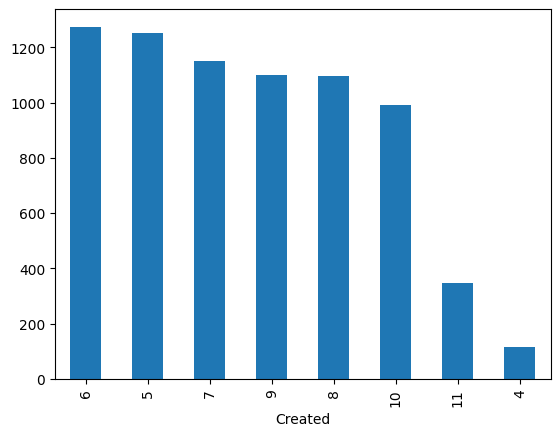

In [65]:
df['Created'].dt.month.value_counts().plot(kind='bar')

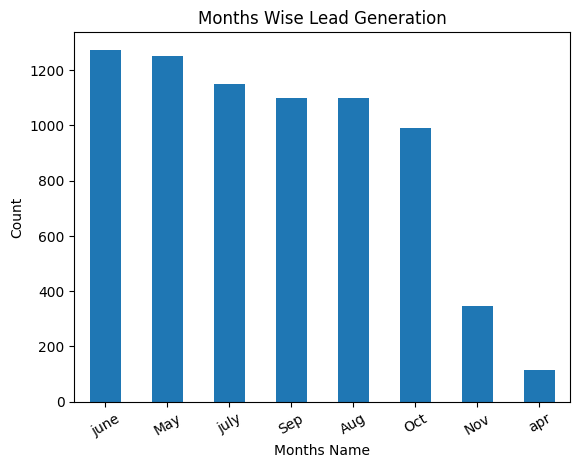

In [66]:
df['Created'].dt.month.map({4:"apr", 5:"May" , 6: "june", 7:"july", 8:"Aug", 9:"Sep" ,10:"Oct",11:"Nov"}).value_counts().plot(kind='bar') 
plt.title("Months Wise Lead Generation")
plt.ylabel("Count")
plt.xlabel("Months Name")
plt.xticks(rotation=30) 
plt.show()

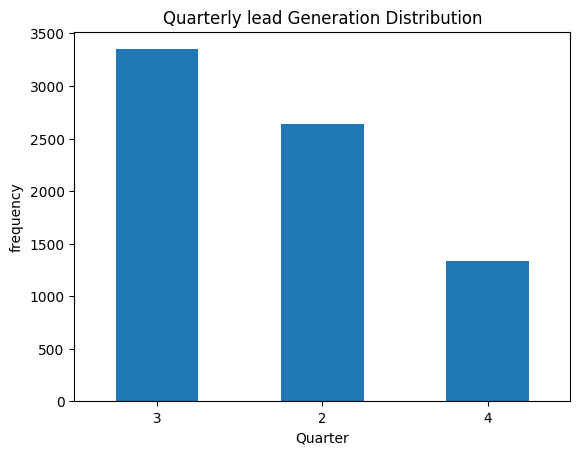

In [67]:
pd. to_datetime(df['Created']).dt.quarter.value_counts().plot(kind='bar')
plt.title("Quarterly lead Generation Distribution") 
plt.xlabel("Quarter")
plt.ylabel("frequency")
plt.xticks(rotation=2)
plt.show()

---
##### Summary ( Interpretation) 
* Data collected only contains year only `2018`
* Highest Leads Months
  * `June (~1270)`
  * `May (~1250)`
**These months generated the highest number of leads.**

**Bussiness Interpretation**  : Bussiness performance was strongest  at months `June,May`.

---
* Medium Performance Months
  * `July`
  * `September`
  * `August`
  * `October`
**Stable performance**
**No extreme drop.**   
 

---

* **Lowest Performance Months**
* `November (~350)`
* `April (~110)`
  
   *Very low compared to others.*

**Possible reasons:**
   * Seasonal slowdown
   * Marketing campaigns stopped
   * Data incomplete
   * Financial quarter changes

**Business Insight**


    Lead generation peaked in May and June, remained stable through mid-year, and significantly dropped in November and April.

----

#### Quarterly Analysis
**The distribution of leads by month indicates a peak during late Q2 (May–June), moderate performance during Q3, and a sharp decline in April and November. This suggests possible seasonal effects influencing lead generation.**

---

### Column Name : Product_ID

In [68]:
print(f"Total Unique Product ID : {df['Product_ID'].nunique()}")

Total Unique Product ID : 29


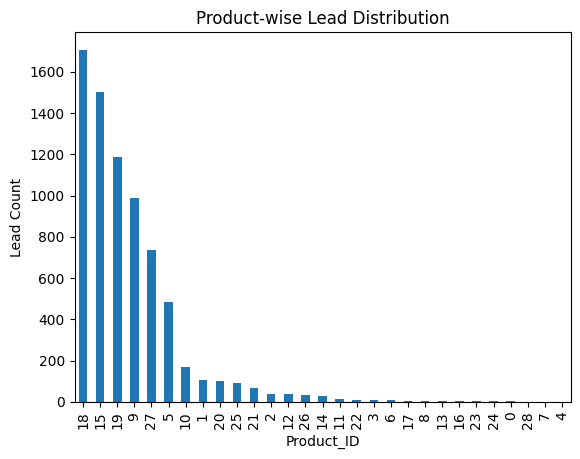

In [69]:
df['Product_ID'].value_counts().plot(kind='bar')
plt.title("Product-wise Lead Distribution")
plt.xlabel("Product_ID")
plt.ylabel("Lead Count")  
plt.show()

In [70]:
df['Product_ID'].value_counts().tail()

Product_ID
24    2
0     2
28    1
7     1
4     1
Name: count, dtype: int64

---
#### Summary 
* Unique Product_Id  only `29` that means some `product ID` are repeatedly used.
---
* Top most Deemanding product Id 

| Product_ID | Count |
|-----|------|
|18   | 1706
|15   | 1501
|19   | 1188
|9    | 990
|27   | 737

---
* Top Least deemanding Product
  
|Product_ID| count 
|---------|------|
|24    | 2       |
|0     | 2       |
|28    | 1       |
|7     | 1       |
|4     | 1       | 

---

### Column name : Source

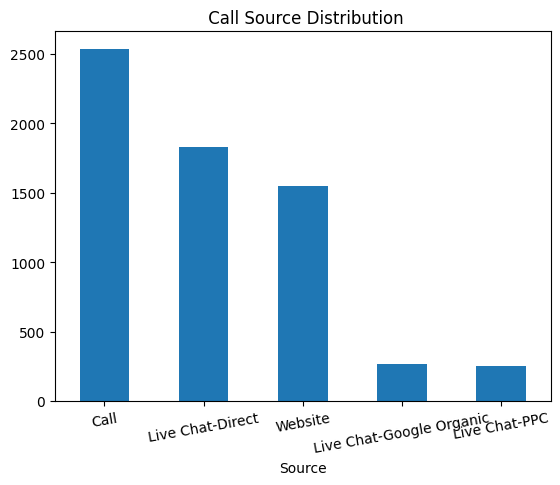

In [71]:
#Distribution
df['Source'].value_counts().head().plot(kind='bar')
plt.xticks(rotation=10)
plt.title(" Call Source Distribution")
plt.show()


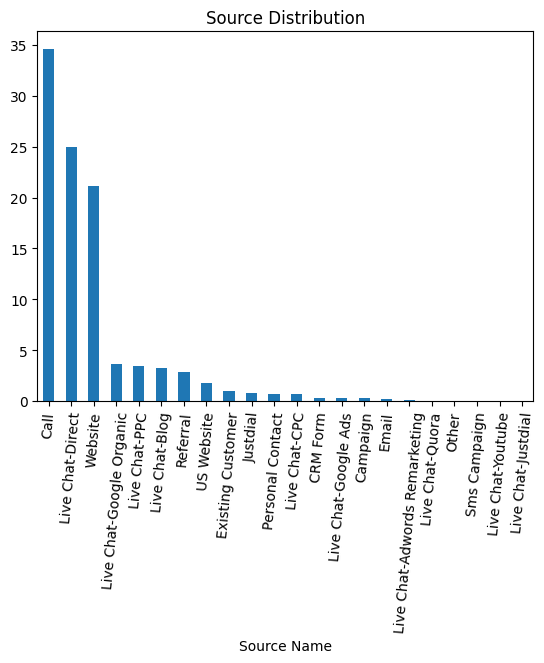

In [72]:
#Distribution
round(df['Source'].value_counts()/len(df)*100,2).plot(kind='bar')
plt.title("Source Distribution")
plt.xlabel("Source Name")
plt.xticks(rotation=85)
plt.show()

---
### Summary 
*  Call Source Generates more Leads as Compare to all source .
*  Sources with top highest Leads
     * Call
     * Live chat-Direct
     * Website
     * Live chat-Google-Organic
     * Live chat-PPC
*  Sources with lowest counts:
     *  Live Chat-Justdial (lowest) only one lead 
     *  Live Chat-Youtube
     *  Sms Campaign
     *  Other
     *  Sms Campaign
     *  Live Chat-Youtube
---

### **Column name :  Sales_Agent**

In [73]:
print(f"No of unique Sales_agent : {df['Sales_Agent'].nunique()}")

No of unique Sales_agent : 11


In [74]:
print(f"Unique Sales_agent : {df['Sales_Agent'].unique()}")

Unique Sales_agent : ['Sales-Agent-3' 'Sales-Agent-4' 'Sales-Agent-11' 'Sales-Agent-7'
 'Sales-Agent-9' 'Sales-Agent-8' 'Sales-Agent-5' 'Sales-Agent-2'
 'Sales-Agent-12' 'Sales-Agent-10' 'Sales-Agent-6']


In [75]:
print(f"Lead Distribution by Sales Agent :\n {round(df['Sales_Agent'].value_counts()/len(df)*100,2)}")

Lead Distribution by Sales Agent :
 Sales_Agent
Sales-Agent-4     20.40
Sales-Agent-11    19.30
Sales-Agent-5     16.13
Sales-Agent-9     11.98
Sales-Agent-3     10.64
Sales-Agent-7     10.02
Sales-Agent-2      5.31
Sales-Agent-12     3.67
Sales-Agent-6      1.56
Sales-Agent-8      0.93
Sales-Agent-10     0.07
Name: count, dtype: float64


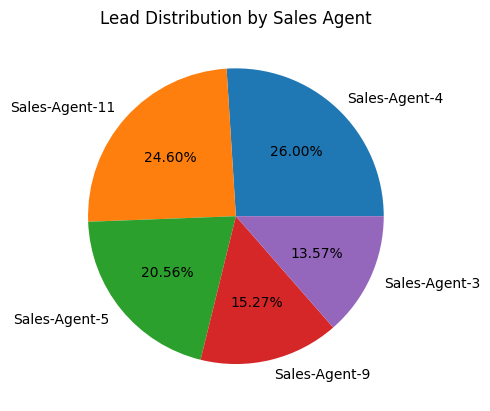

In [76]:
sales_counts = df['Sales_Agent'].value_counts().head()
plt.pie(sales_counts,labels=sales_counts.index,autopct='%1.2f%%')
plt.title("Lead Distribution by Sales Agent")
plt.show()

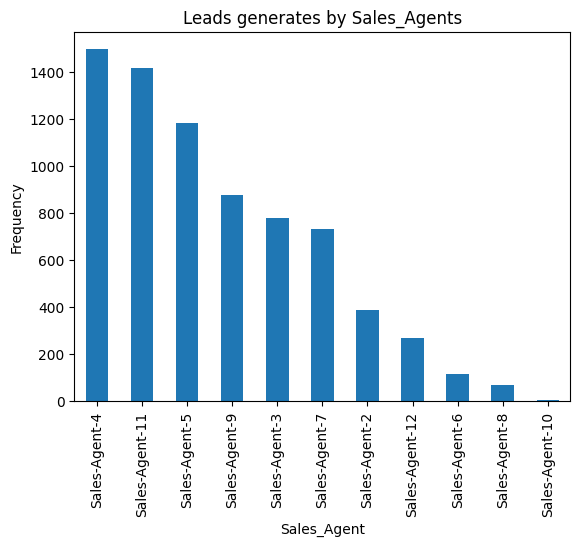

In [77]:
df['Sales_Agent'].value_counts().plot(kind='bar')
plt.ylabel("Frequency")
plt.title("Leads generates by Sales_Agents")

plt.show()

In [78]:
df['Sales_Agent'].value_counts().tail()

Sales_Agent
Sales-Agent-2     389
Sales-Agent-12    269
Sales-Agent-6     114
Sales-Agent-8      68
Sales-Agent-10      5
Name: count, dtype: int64

---
### Summary
*  Count of sales_agent  : 11
* Top Sales agent which generates higher leads
|Agent | %of Leads Generates
|------|-------|
|Sales-Agent-4   | 20.40% 
|Sales-Agent-11  | 19.30%
|Sales-Agent-5   | 16.13%
|Sales-Agent-9   | 11.98%
|Sales-Agent-3   | 10.64%
|Sales-Agent-7   | 10.02%

* Sales_agent_10 generates only 5 leads.

---


### Column name :  Location 

In [79]:
print(f"Unique Location :  {df['Location'].nunique()}")   

Unique Location :  16


In [80]:
print(f"List of unique Location : \n  {df['Location'].unique()}")   

List of unique Location : 
  ['Bangalore' 'Others' 'Trivandrum' 'Hyderabad' 'Chennai' 'Uk' 'Usa'
 'Delhi' 'Uae' 'Mumbai' 'Kolkata' 'Singapore' 'Pune' 'Australia' 'Europe'
 'Malaysia']


In [81]:
df['Location'].value_counts()

Location
Others        2481
Bangalore     2079
Chennai        907
Hyderabad      527
Delhi          470
Mumbai         399
Pune           139
Uae             77
Trivandrum      58
Kolkata         56
Usa             45
Uk              41
Australia       25
Singapore       17
Malaysia         4
Europe           3
Name: count, dtype: int64

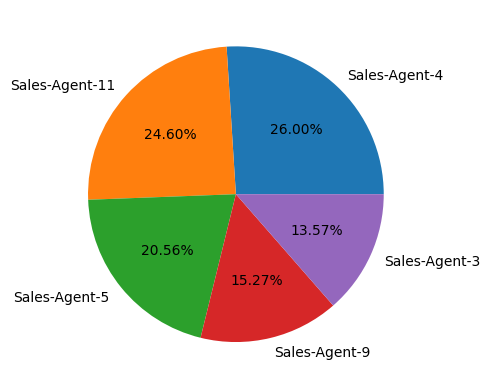

In [82]:
df['Location'].value_counts().head()
plt.pie(sales_counts,labels=sales_counts.index,autopct='%1.2f%%')
plt.show()

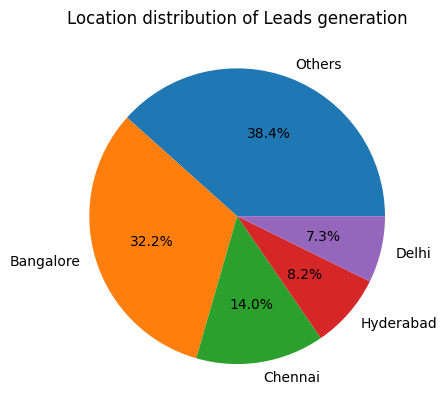

In [83]:
plt.pie(x= df['Location'].value_counts().head(),labels=df['Location'].value_counts().head().index,autopct='%1.1f%%') 
plt.title("Location distribution of Leads generation")
plt.show()

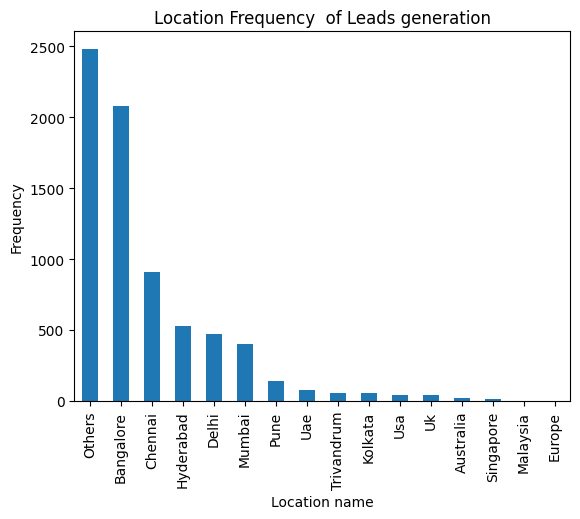

In [84]:
df['Location'].value_counts().plot(kind='bar')
plt.xlabel("Location name")
plt.ylabel("Frequency")
plt.title("Location Frequency  of Leads generation")
plt.show()

In [85]:
df['Location'].value_counts().tail()

Location
Uk           41
Australia    25
Singapore    17
Malaysia      4
Europe        3
Name: count, dtype: int64

---
### Summary 
* Total no. of unique Location : `16`
* List of Unique Location:
   * Bangalore
   * Others
   * Trivandrum
   * Hyderabad
   * Chennai
   * Uk
   * Usa
   * Delhi
   * Uae
   * Mumbai
   * Kolkata
   * Singapore
   * Pune
   * Australia,
   * Europe
   * Malaysia
*  Top most Leads generates  location
   * ( Others , Bangalore , Chennai , Hyderabad , Delhi,Mumbai,Pune)
* Top Least Leads Generation location
   * (Europe , Malaysia , Singapore , Australia , UK)
---
 
* **Both location `Delhi & mumbai` shows moderate leads generation.**

---

### Column name :  Delivery_Mode

In [86]:
print(f"No of Delivery mode : {df['Delivery_Mode'].nunique()}")


No of Delivery mode : 5


In [87]:
print(f"Delivery mode Name : {df['Delivery_Mode'].unique()}")

Delivery mode Name : ['Mode-1' 'Mode-5' 'Mode-3' 'Mode-2' 'Mode-4']


<Axes: xlabel='Delivery_Mode'>

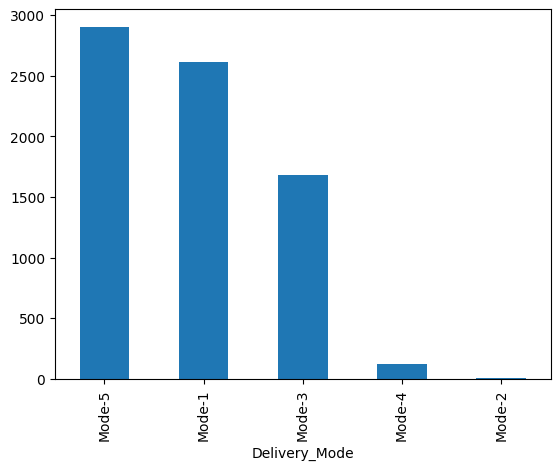

In [88]:
df['Delivery_Mode'].value_counts().plot(kind='bar')

--
### Summary : 
* Number of Delivery Mode : `5`
* Delivery mode Name : Mode-1,Mode-2,Mode-3,Mode-4,Mode-5.
* `Mode-5,mode -1` has higher delivery mode.
---


### Column name : Source_Clean

*The Source_Clean variable represents the different lead acquisition channels after data cleaning and standardization.*

In [89]:
df['Source_Clean'].nunique()

14

In [90]:
df['Source_Clean'].unique()

array(['Live Chat', 'Call', 'Website', 'By Recommendation',
       'Customer Referral', 'Email', 'Existing Customer', 'Us Website',
       'Justdial', 'Campaign', 'Other', 'Crm Form', 'Sms Campaign',
       'Personal Contact'], dtype=object)

In [91]:
df['Source_Clean'].value_counts()

Source_Clean
Live Chat            2663
Call                 2536
Website              1551
Customer Referral     180
Us Website            129
Existing Customer      73
Justdial               56
Personal Contact       50
By Recommendation      32
Crm Form               22
Campaign               19
Email                  13
Other                   2
Sms Campaign            2
Name: count, dtype: int64

### Summary
* The `Source_clean` column contains 14 disticnt lead acquisition channnels after standerdization.
* `Live chat 2663 leads` is the  highest contributing source.
* `Call - 2536 leads` is the second major source.
* `website - 1551 leads` also   contribute a significant share.
* The top three source (Live chat,Call , Website)  account for the majority of total leads. 
* Very low contribution channels include :
   *  Email (13)
   *  Campaign (19)
   *  SMS Campaign(2)
   *  Others(2)
* **The distribution is highly skewed, with most leads concentrated in a few dominant channels.**
* *This Inndicates : Heavy relies on `Live chat and call-based lead generation.*
* *Several minor channels contribute minor volume.*
---


### Column name : Is_International
* This column usually represents whether a lead is:
  * Domestic (0 / No)
  * International (1 / Yes)
*It is typically a binary categorical variable.*

In [92]:
df['Is_International'].unique()

array([0, 1])

In [93]:
round(df['Is_International'].value_counts()/len(df)*100,2)

Is_International
0    97.11
1     2.89
Name: count, dtype: float64

### Summary 
*  only `2` unique values 0 means -  No , 1- Yes.
*  Domestic leads(0) - `7116`
*  International Leads (1) - `212`
*  **Percentage Share**
    * Domestic ~ 97.1%
    * International ~ 2.9%
---
**key Insight**
* The dataset is highly imbalanced.
* The vast majority of leads are domestic.
* International leads form a very small segment (~3%).
* The business is primarily focused on domestic market.

---

### Column name : Lead_category
`Lead_category` is a categorical_variable 

In [94]:
df['Lead_category'].unique() # unique values 

array(['high_potential', 'Low_potential'], dtype=object)

In [95]:
df['Lead_category'].value_counts()

Lead_category
Low_potential     4485
high_potential    2843
Name: count, dtype: int64

In [96]:
round(df['Lead_category'].value_counts()/len(df)*100,2)

Lead_category
Low_potential     61.2
high_potential    38.8
Name: count, dtype: float64

---
### Summary 
* 2 types of leads exist
* Low_potential    4485 leads
* high_potential   2843 leads
* **percentage share**
* Low potential : 61.2%
* High potential : 38.8%
* *Majority of the leads(around 61 %) are categorized as `Low Potential`*
* *Around 39% of leads are High Potential.*
* *The distribution is moderately imbalanced.*
---

### **Column name : Status**

In [97]:
print(df['Status'].unique())

['POTENTIAL' 'NOT RESPONDING' 'IN PROGRESS POSITIVE' 'JUST ENQUIRY'
 'JUNK LEAD' 'CONVERTED' 'IN PROGRESS NEGATIVE' 'OPEN' 'LOST' 'LONG TERM']


In [98]:
df['Status'].value_counts()


Status
JUNK LEAD               1532
NOT RESPONDING          1119
CONVERTED                852
JUST ENQUIRY             751
POTENTIAL                705
LONG TERM                644
IN PROGRESS POSITIVE     642
IN PROGRESS NEGATIVE     625
LOST                     439
OPEN                      19
Name: count, dtype: int64

### Summary 
* **Status dsitribution**
| Status               | Count |
| -------------------- | ----- |
| JUNK LEAD            | 1532  |
| NOT RESPONDING       | 1119  |
| CONVERTED            | 852   |
| JUST ENQUIRY         | 751   |
| POTENTIAL            | 705   |
| LONG TERM            | 644   |
| IN PROGRESS POSITIVE | 642   |
| IN PROGRESS NEGATIVE | 625   |
| LOST                 | 439   |
| OPEN                 | 19    |

**Insight**
* **Most Common Status**
   * JUNK LEAD (1532) is highest.
   * Indicates large number of low-quality leads.

* **Conversion Count**
  * CONVERTED = 852
  * Conversion rate ≈ 11.6% , Only ~11.6% leads convert.
  * High number of junk & non-responding leads.
  * Quality filtering before sales assignment may improve efficiency.
----
----

## 6. Bivariate & Multivariate Analysis

---
* **Categorical vs Lead_category**
   * Product_ID
   * Source_Clean
   * Sales_Agent
   *  Location
   * Delivery_Mode
   * Is_International
   * Status
---
* **Time-Based vs Lead_category**
    * Month
    * Year
* *Bivariate analysis was conducted by comparing categorical variables against the binary target (Lead_category) using normalized cross-tabulation and 100% stacked bar charts to evaluate distribution differences and predictive strength.*

---

### Product_ID vs Lead_category

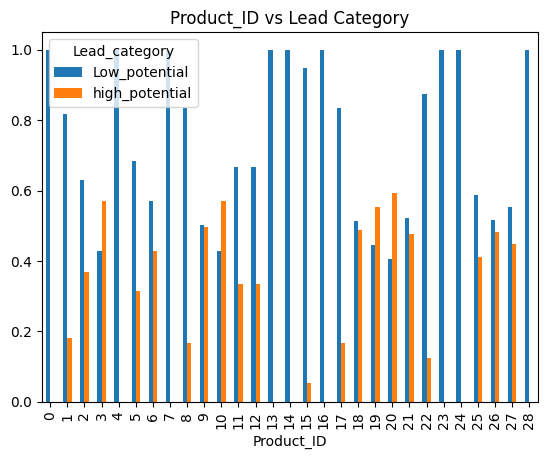

In [99]:
ct = pd.crosstab(df['Product_ID'], df['Lead_category'], normalize='index')
ct.plot(kind='bar', stacked=False)
plt.title("Product_ID vs Lead Category")
plt.show()


---
### **Interpretation: Product_ID vs Lead_category**
* Blue --> Low_potential
* Orange --> High_potential
* **Key Observation**
  * Strong Performing Product
     * Product 3
     * Product 10
     * Product 20
     * Product 21
     * Product 26
  *These products generates camparatively more high_potential leads.*
---

* **Weak performing Products**
  **Products where orange bar is very small:**
   * Product 14
   * Product 15
   * Product 7
   * Product 22
*These Products mostly generates Low_potential leads.*
**Highly Imbalanced Products**
  * Some products are almost entirely Low_potential.
  * That means: They may not be good predictors for high-quality leads.
     Or they attract wrong audience segment.

---

### Source_Clean vs Lead_category

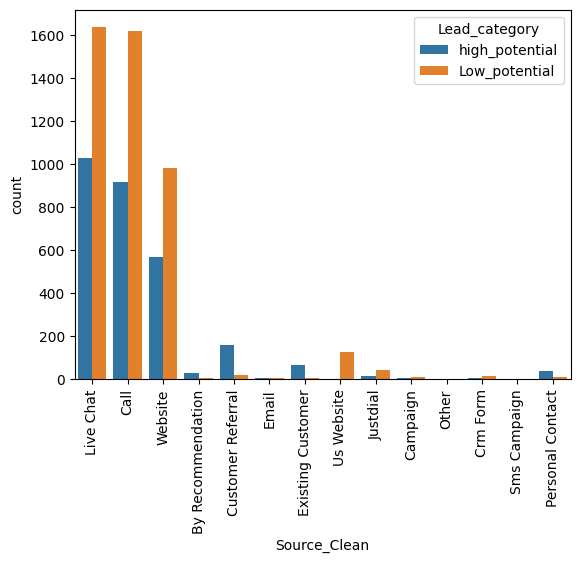

In [100]:
sns.countplot(data=df, x='Source_Clean', hue='Lead_category')
plt.xticks(rotation=90)
plt.show()

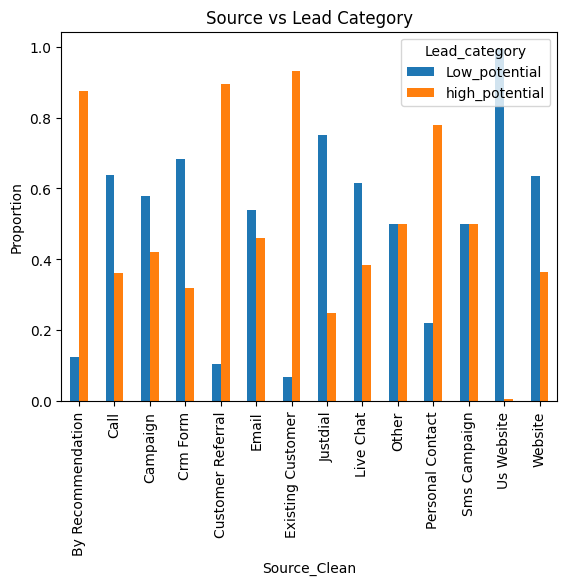

In [101]:
ct = pd.crosstab(df['Source_Clean'], df['Lead_category'], normalize='index')
ct.plot(kind='bar', stacked=False)
plt.title("Source vs Lead Category")
plt.ylabel("Proportion")
plt.show()

### Summary 
* The highest lead sources are :
  * Live chat 
  * Call
  * Website
*These 3 dominate total lead generation*
  * **For Major sources**
  * **Live chat**
    * Low_potential significantly higher than High_potential.
    * Large volume but moderate quality.
  * **Call**
    * Similar pattern
    * High volume but more low-quality leads.
  * **Website**
    * Still more low_potential , but proportion gap looks smaller than live chat.
---
* High quality Sources
 * Existing Customer  ~93% high_potential
   * *Extremely strong quality source.*
 * Customer referral ~90% high_potential
    * Referral leads are very high intent.
  * By Recommandation ~87% High_potential
    * Word-of-mouth works best.
  * Personal Contact
    * ~78% High_potential
* Weak Quality Sources
    * Us Website
    * CRM Form
    * Justdial
    * Live Chat
**Very Important Business Insight**

   * High Volume ≠ High Quality
   * Live Chat & Call → Huge volume, lower proportion

--- 

### Sales_Agent vs Lead_category

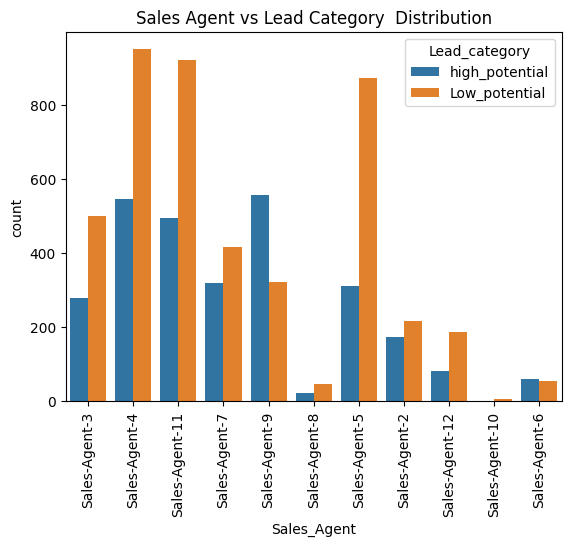

In [102]:
sns.countplot(data=df,x= "Sales_Agent",hue="Lead_category")
plt.xticks(rotation=90)
plt.title("Sales Agent vs Lead Category  Distribution")
plt.show()

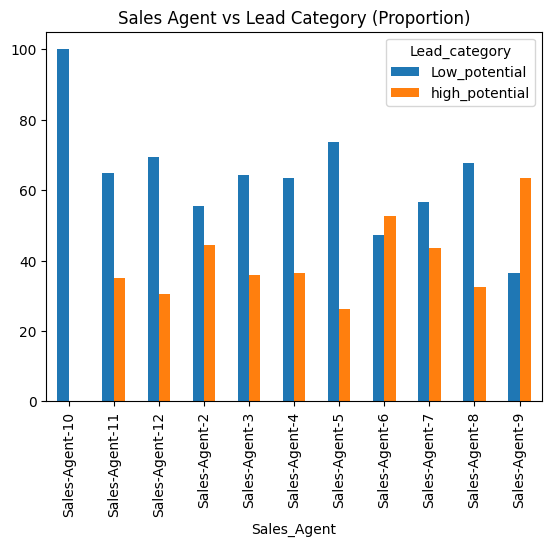

In [103]:
ct = pd.crosstab(df['Sales_Agent'], df['Lead_category'], normalize='index')*100
ct.plot(kind='bar', stacked=False)
plt.title("Sales Agent vs Lead Category (Proportion)")
plt.show()


---
### summary :
* Agents handling most leads :
  * Sales-Agent-4
  * Sales-Agent-11
  * Sales-Agent-5
* *Sales-Agent-9 possibly better quality handling*
* Weak Agents
  * Some agents show:
    * Very low high_potential
    * High low_potential ratio
**These may need: Training,Better lead allocation,Performance review**
---
* **Top Performing Agents (High % High_potential)**
  * Sales-Agent-9
    * ~63% high_potential
    *  *Best performing Agent in term of Quality*
* Moderate Performance Agents
    * Sales-Agent-7 (~43%)
    * Sales-Agent-4 (~37%)
    * Sales-Agent-3 (~36%)
**These agents show balanced distribution.**

* **Weak Performing Agents**
  * **Sales-Agent-10**
     * ~0% High_potential
     *  Extremely weak (almost all low potential).

  * **Sales-Agent-5**
     * ~26% High_potential
  * **Sales-Agent-12**
     * ~30% High_potential

*These agents mostly handle low-potential leads.*

----

### Location vs Lead Category 

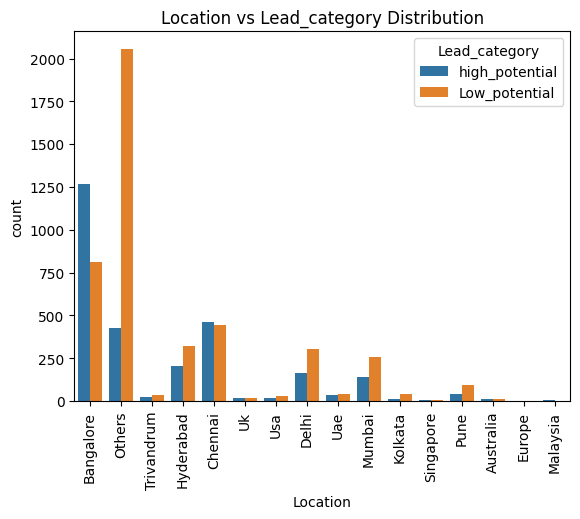

In [104]:
sns.countplot(data= df , x= df['Location'],hue= 'Lead_category')
plt.title("Location vs Lead_category Distribution")
plt.xticks(rotation=90)
plt.show()

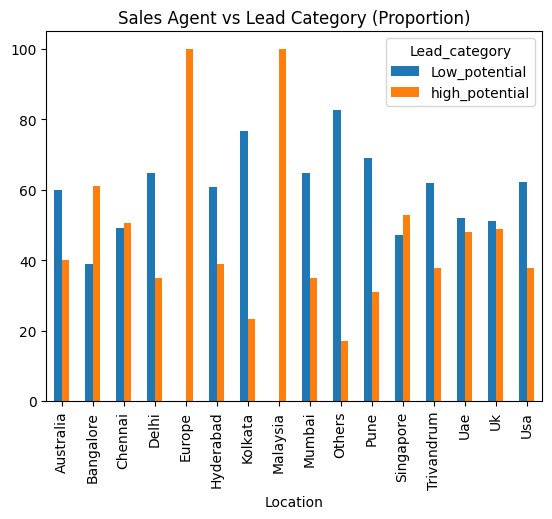

In [105]:
ct = pd.crosstab(df['Location'], df['Lead_category'], normalize='index')*100
ct.plot(kind='bar', stacked=False)
plt.title("Sales Agent vs Lead Category (Proportion)")
plt.show()

---
### Summary 
*  `Others` have Largest volume overall ( mostly Low potential)
*  `Banglore` have high total leads  and comparatively strong high_potential count.
*  `Chennai` balanced distribution.
*  `Hyderabad` have mostly  `Low potential` as compare to `high_potential.`
---
**Key Insights**
* Strong Performing Locations (High % High_potential)
  * Malaysia :  ~100% High_potential  But likely very small sample size.
  * Europe   : ~100% High_potential . Again very small data count.
  * Bangalore: ~61% High_potential.This is strong and reliable because Bangalore also has high volume.

  * Singapore : ~53% High_potential . Above average quality.

* **Moderate / Balanced Locations**
  * Chennai (~50%)
  * UAE (~48%)
  * UK (~49%)

 * *These locations are balanced — neither strongly high nor low.*

* Weak Performing Locations
  * Others : ~17% High_potential . Very low quality despite high volume.
  * Kolkata: ~23% High_potential
  * Pune   : ~31% High_potential
 * *These regions mostly produce low-potential leads.*
---
**Important Observation**
* Europe and Malaysia look perfect (100%),
* But earlier count plot showed very low volume.
---


### Delivery_Mode vs Lead_category

<Axes: xlabel='Delivery_Mode', ylabel='count'>

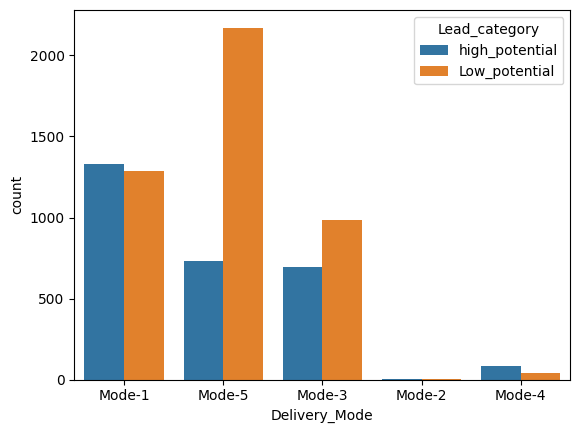

In [106]:
sns.countplot(data=df,x= df['Delivery_Mode'], hue=df['Lead_category'])


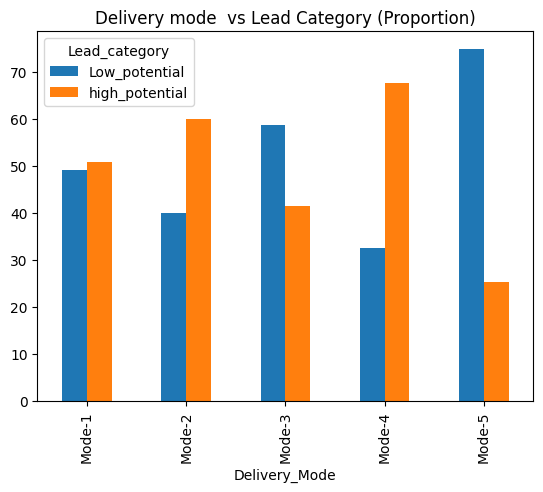

In [107]:
ct = pd.crosstab(df['Delivery_Mode'], df['Lead_category'], normalize='index')*100
ct.plot(kind='bar', stacked=False)
plt.title("Delivery mode  vs Lead Category (Proportion)")
plt.show()

### Summary 
*  **Key Observations (Countplot)**
   * Mode-1 -> Strong & Balnaced
      * High Potential ~ 1300+
      * Low Potential ~1250+
      * Very balanced distribution.
      * Also high total volume.
      * *Mode-1 is a strong and stable delivery mode.*
   * Mode-5 -> High volume but poor quality
      * Very high  Low_potential (~2200+)
      * High_potential much lower (~700+)
      * *Generates large traffic but in low quality leads.*
   * Mode-3 -> Moderate Performance
      * Low potential slightly higher then high_potential.
   * Mode-2 -> Very small volume
      * Almost no leads.
      * Not statistically important.
   * Mode-4 -> Small
      * Higher Potential greater than Low_potential
      * But very low total volume
      * *Looks good in quality, but volume is too small.*
---

* **Key observation (Proportion)**
  * Best performing Mode  - Mode-4
     * Only 67% high_potential
     * only 33% Low_potential
     * *Best Quality delivery mode.*
  * Strong mode - mode-2
     * ~60% High_potential
     * Very good proportionally
  * Balanced mode - mode -1
     * ~51% high_potential
     * Almost balanced

---

### Is_International vs Lead_category

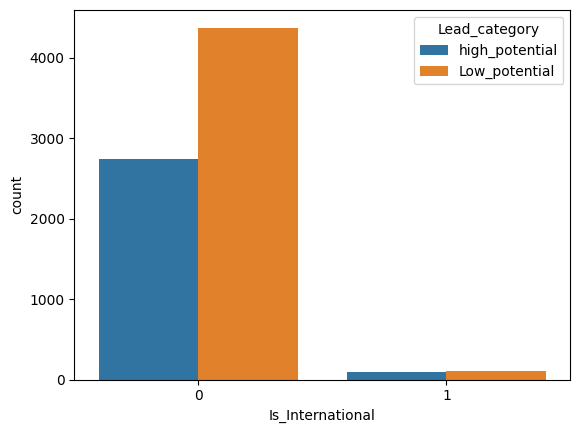

In [108]:
sns.countplot(data=df,x= df['Is_International'], hue=df['Lead_category'])
plt.show()

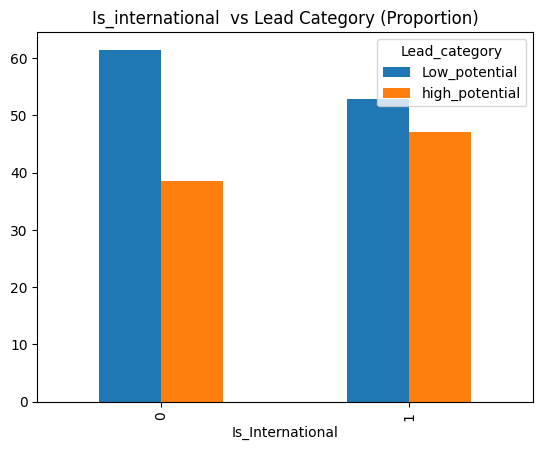

In [109]:
ct = pd.crosstab(df['Is_International'], df['Lead_category'], normalize='index')*100
ct.plot(kind='bar', stacked=False)
plt.title("Is_international  vs Lead Category (Proportion)")
plt.show()

### Summary 
* **Observation(countplot)**
  * Domestic Leads (0)
    * Very high total volume.
    * High_potential ≈ 2700+
    * Low_potential ≈ 4400+
    * *Majority of business comes from domestic market.But Low_potential dominates.*
    * Domestic leads = high volume, moderate quality.
    
 * International Leads (1)
    * Very small volume.

*High and Low counts are almost equal.*

*Much smaller contribution overall.*

**International market is very small in dataset.**

---
* **Key Observations( proportion)**
  * Domestic Leads (0)
    * ~61% Low_potential
    * ~39% High_potential

    * **Majority of domestic leads are low-potential.**

* **International Leads (1)**
    * ~53% Low_potential
    * ~47% High_potential
    * **International leads have better quality ratio than domestic.**
---

###  Time based vs lead_category
Steps to perform time based analysis
* extract manths and year
* cross_tab between months vs lead_category

In [110]:
df['months'] = df['Created'].dt.month_name()

In [111]:
ct_month = pd.crosstab(df['months'], df['Lead_category'], normalize='index') * 100
ct_month

Lead_category,Low_potential,high_potential
months,,
April,59.130435,40.869565
August,62.932605,37.067395
July,64.869565,35.130435
June,65.306122,34.693878
May,65.894569,34.105431
November,49.279539,50.720461
October,54.435484,45.564516
September,55.636364,44.363636


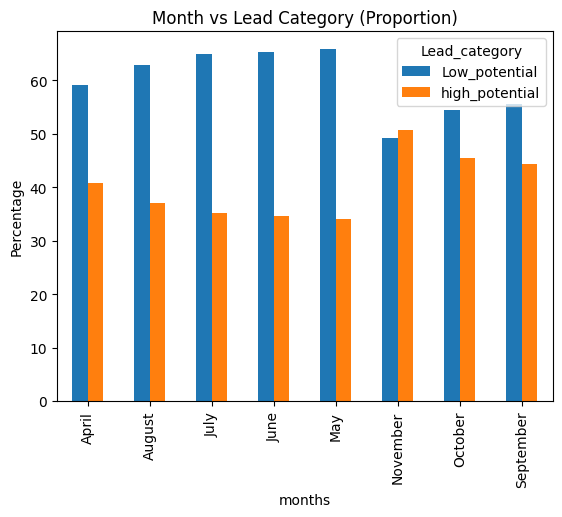

In [112]:
ct_month.plot(kind='bar', stacked=False)
plt.title("Month vs Lead Category (Proportion)")
plt.ylabel("Percentage")
plt.show()

### Summary 
* **Key Observations(porportion)**
  * Best Performing Month
    *  November  ~51% High_potential
    * This is the only month where High_potential exceeds Low_potential.
    * November has the best lead quality.

  * Strong Months
   * September ~45% High_potential
   * October   ~45–46% High_potential
   *  Late-year months show improvement in quality.

 * Weak Months
   * May  ~34% High_potential
   * June ~35% High_potential
   * July ~35% High_potential
   * Mid-year months have lower lead quality.
---

## 7. Complete Report on  Data exploration insights – Sales effectiveness(Task -1 completed)


### Task-1: 1. Data exploration insights – Sales effectiveness.
*  Objective
  * The objective of this analysis was to:
     * Understand dataset structure
     * Perform univariate and bivariate analysis
     * Identify factors influencing lead quality
     * Detect patterns and seasonal trends
     * Target Variable:
      * Lead_category (Binary Classification)
        * High_potential
        * Low_potential

* Dataset Overview
**Columns Analyzed:**
  * Created (Date)
  * Product_ID
  * Sales_Agent
  * Location
  * Delivery_Mode
  * Source_Clean
  * Is_International
  * Lead_category (Target)
   * Total Records: ~7328
* **Lead Category Distribution:**
  * Low_potential ~ 61%
  * High_potential ~ 39%
  * **The dataset shows moderate class imbalance.**

*  Univariate Analysis
  * Lead_category
   * Majority leads are Low_potential (~61%).
   * Moderate imbalance but manageable for classification.

  * Source_Clean
   * Live Chat, Call, Website generate majority of leads.
   * Several minor sources contribute negligible volume.

  * Delivery_Mode
   * Mode-5 generates highest volume.
   * Mode-1 and Mode-3 moderate volume.
 
  * Location
   * Majority leads come from Bangalore and Others.
   * Some international regions have very low volume.

  * Is_International
   * 97% Domestic
   * 3% International

**Highly imbalanced feature.**

---
**Bivariate Analysis (Feature vs Target)**

  * **Product_ID vs Lead_category**
    * Certain products show higher proportion of High_potential.
    * Product_ID is a strong predictive feature.

  * **Source_Clean vs Lead_category**
   * Referral and Existing Customer sources have highest % High_potential.
   * Live Chat & Call generate high volume but lower quality.
   * Clear variation across channels.

 * **Sales_Agent vs Lead_category**
   * Significant variation among agents.
   * Some agents consistently associated with higher High_potential ratio.
   * Possible performance or allocation differences.
 * **Location vs Lead_category**
   * Bangalore shows strong quality + volume.
   * “Others” category dominated by Low_potential.
   * Some regions show 100% High_potential but very low sample size.
   * Small-sample caution applied.

 * **Delivery_Mode vs Lead_category**
   * Mode-4 and Mode-2 show higher High_potential proportion.
   * Mode-5 dominated by Low_potential (~75%).
   * Delivery mode impacts lead quality significantly.
 * Is_International vs Lead_category
   * International leads show slightly better quality ratio (47% vs 39%).
   * But very small volume → limited business impact.

* **Time-Based Analysis**
   * Month vs Lead_category
  * Seasonal trend observed:
    * May–July → Lower High_potential proportion (~34–35%)
    * September–November → Higher High_potential (~45–51%)
    * November performs best.
    * Indicates seasonal variation in lead quality.

* **Key Business Insights**

    * Lead quality varies significantly across channels and delivery modes.
    * Referral and Existing Customer sources generate highest quality leads.
    * Bangalore is the strongest reliable geographic market.
    * Mode-5 delivery channel requires optimization.
    * Sales agent performance differences exist.
    * Seasonal variation suggests stronger Q4 performance.

* **Feature Strength Summary**
  * Strong Predictors:
    * Source_Clean
    * Product_ID
    * Delivery_Mode
    * Sales_Agent
    * Month

* **Moderate Predictors:**
    * Location
* **Weak Predictor:**
    * Is_International (due to imbalance)

* **Data Challenges Identified**
    * Class imbalance (61/39 split)
    * High cardinality categorical features
    * Small-sample categories
    * “Others” grouping may hide variation

**Some inconsistent category naming (cleaned earlier)**

* **Recommendations Before Modeling**
    * Apply One-Hot Encoding for categorical variables.
    * Consider seasonal feature engineering (Month).
---
### Final Goal Alignment Statement

*Through exploratory data analysis, key drivers of lead quality were identified across sources, agents, locations, delivery modes, and time periods. These insights directly support improving sales effectiveness by enabling better lead prioritization, optimized resource allocation, and strategic decision-making.*

---
**The dataset is suitable for building a binary classification model to predict lead potential.**

---
**Task-1 Status**

 * Data Cleaning Completed
 * Univariate Analysis Completed
 * Bivariate Analysis Completed
 * Time-Based Analysis Completed
 * Business Insights Derived
 * Data exploration insights – Sales effectiveness.

**Task-1: Successfully Completed**

---
---

## 8. 2. ML model to predict the Lead Category (High Potential , Low Potential).

### Data Preprocessing 
* Before Applying  Any Machine Learning we  required data preprocessing step
  * Remove Unnecessary Column :  `Status , Source , Months.`
  * Handle Date Column (Created)

In [113]:
df.drop(columns=['Status','Source','months'],inplace=True,errors='ignore')
print("Successfully removed column : Status , Source , Months")

Successfully removed column : Status , Source , Months


#### **Handle Date Column (Created)**

In [114]:
df['Month'] = df['Created'].dt.month
df['Day'] = df['Created'].dt.day
df['Hour'] = df['Created'].dt.hour
df = df.drop(columns=['Created'])

#### Mapping  target column to 'Low_potential: 0 , high_potential:1 . 

In [115]:
df['Lead_category'] = df['Lead_category'].map({
    "Low_potential" : 0,
    "high_potential" : 1}
                                             )
print("Target column convert into  encoded form")

Target column convert into  encoded form


#### Categorize the feature into categorical_feature and numeric_feature 

In [116]:
categorical_features = ['Product_ID','Source_Clean','Sales_Agent','Location','Delivery_Mode']

numeric_features = ['Is_International','Month','Day','Hour']

####  **split a dataset into 2 parts train and testing part.** 

In [117]:
from sklearn.model_selection import train_test_split
x= df.drop('Lead_category',axis=1)
y= df['Lead_category']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#### Build Pre-processor

In [118]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(drop='first', handle_unknown='ignore'),categorical_features),
        ('num',StandardScaler(),numeric_features)
    ]
)

#### Applying Multiple ML model on Dataset 

##### Pipeline for Logistic  Regression

In [119]:
log_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('classifier',LogisticRegression())
]  )

In [120]:
# Used Hyperparameter tunning for improve model Accuracy 
from sklearn.model_selection import GridSearchCV 

In [121]:
param_grid_log = {
    "classifier__C" : [0.01,0.1,1],
    "classifier__penalty": ["l2"],
    "classifier__max_iter":[100,200,300,400],
    "classifier__class_weight":[None,'balanced']
}

In [122]:
grid_log  = GridSearchCV(
    estimator= log_pipeline,
    param_grid= param_grid_log,
    cv=5,
    scoring="recall",n_jobs=-1, verbose=2)

In [123]:
grid_log.fit(x_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__max_iter': [100, 200, ...], 'classifier__penalty': ['l2']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [124]:
print("Best Parameters:\n", grid_log.best_params_)

print("Best Recall Score:",grid_log.best_score_)

Best Parameters:
 {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 100, 'classifier__penalty': 'l2'}
Best Recall Score: 0.756


In [125]:
y_pred_log = grid_log.predict(x_test)
log_accuracy = accuracy_score(y_test, y_pred_log)
log_recall   = recall_score(y_test,y_pred_log)
log_f1 = f1_score(y_test,y_pred_log)
print(F"Logistic Regression Accuracy: {round(log_accuracy,2)*100}%")
print(F"Logistic Regression recall: {round(log_recall,2)*100}%")
print(F"Logistic Regression f1_score: {round(log_f1,2)*100}%")


Logistic Regression Accuracy: 70.0%
Logistic Regression recall: 77.0%
Logistic Regression f1_score: 67.0%


---
### Machine Learning model Report 
* **Algorithm : Logistic Regression**
* **Objective : Predict Lead quality (high vs Low Potential)**
* **Why Logistic Regression?**
  * Baseline classification model
  * Interpretable
  * Works well for binary classification
  * Provides probability outputs for threshold tuning.
*  **Evaluation Metrics**
  *Since bussiness priority is identifying high_potential leads,focus was placed on*
   * Recall (import metric )
   * F1_score
   * Accuracy ( checks model prediction)   
* **Model Performance**
| Metric | Score |
|--------|-------|
Accuracy | 70%   |
Recall(high_potential) | 77.0%|
F1-score | 67.0% |

---

**Accuracy - 70%**
  * Model correctly predict 70% of total leads.
  * Improves Significantly over baseline (~61%)

**Recall - 77%  (Most Important)**

  * Model correctly identifies 77% of high_potential leads.
  * This means most valuable leads are missed.
*This is strong performance for a linear model.*

**F1-Score – 67%**

 * Indicates balanced performance between precision and recall.
 * Suggests acceptable trade-off between:
   * Missing good leads
   * Sending low-quality leads to sales
**Business Impact**
   * Sales team can prioritize 77% of high-value leads.
   * Reduces chances of missing valuable customers.
   * Improves lead allocation efficiency.
   * Provides probability scores for further threshold tuning.
**Model Limitations**
   * Assumes linear relationship
   * May not capture complex feature interactions.
   * Precision Moderate (Some False positive exist)
---
#### **Summary** 
The model effectively identifies high-quality leads and provides a strong baseline for further improvement using ensemble methods.

---

In [126]:
from sklearn.metrics import classification_report ,confusion_matrix
print(f"               classification_report\n                --------------------\n {classification_report(y_test,grid_log.predict(x_test))}")
print(f"                  Confusion_matrix\n                 --------------------\n{confusion_matrix(y_test,grid_log.predict(x_test))}") 

               classification_report
                --------------------
               precision    recall  f1-score   support

           0       0.81      0.66      0.72       873
           1       0.60      0.77      0.67       593

    accuracy                           0.70      1466
   macro avg       0.70      0.71      0.70      1466
weighted avg       0.72      0.70      0.70      1466

                  Confusion_matrix
                 --------------------
[[572 301]
 [138 455]]


---
### Machine Learning Model Evaluation Report 
  **Model : Logistic Regression**

#### **Classsification Report Summary**
| Metric    | Class 0 (Low) | Class 1 (High) |
| --------- | ------------- | -------------- |
| Precision | 0.81          | 0.60           |
| Recall    | 0.66          | 0.77           |
| F1-score  | 0.72          | 0.67           |

**Overall Metrics:**
 * Accuracy: 70%
 * Macro Average F1: 70%
 * Weighted Average F1: 70%

#### **Confusion Matrix Interpretation**
Meaning : 
 * True Negatives ( Correct Low) : 572
 * False positives ( Predicted high but low) : 301
 * False Negatives ( Missed high Leads ) : 138
 * True Positives (Correct High ) : 455 
#### Summary 
*The Logistic Regression model provides reliable and business-relevant predictions, effectively identifying high-potential leads with strong recall performance, making it suitable for assisting sales prioritization strategies.*

---

#### Algorithm Name : Decision tree classifier (tree based Model) 

In [127]:
dt_pipeline =  Pipeline( steps=
                         [
                             ('preprocessing',preprocessor),
                             ('classifier',DecisionTreeClassifier())
                         ]
                       )

In [128]:
param_grid_dt = {
    "classifier__criterion" : ["gini", "entropy", "log_loss"],
    "classifier__max_depth" :[None,10,20,30],
    "classifier__min_samples_split":[2,4,6],
    "classifier__min_samples_leaf" :[1,2,5] }
    

In [129]:
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid_dt,
    cv=5,
    scoring='recall',   # because high_potential is important
    n_jobs=-1,
    verbose=2
)

In [130]:
dt_grid.fit(x_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,Pipeline(step...lassifier())])
,param_grid,"{'classifier__criterion': ['gini', 'entropy', ...], 'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 4, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [131]:
y_pred_dt    = dt_grid.predict(x_test)
dt_accuracy  = accuracy_score(y_test,y_pred_dt)
dt_recall    = recall_score(y_test,y_pred_dt)
dt_f1        = f1_score(y_test,y_pred_dt)
print(f"Decision Tree Accuracy  : {round(dt_accuracy,2)*100}%")
print(f"Decision Tree recall    : {round(dt_recall,1)*100}%")
print(f"Decision Tree f1_score  : {round(dt_f1,1)*100}%")

Decision Tree Accuracy  : 66.0%
Decision Tree recall    : 60.0%
Decision Tree f1_score  : 60.0%


#### **Summary** 
*The Decision Tree classifier achieved 66% accuracy and 50% recall for high-potential leads. Due to its relatively low recall and weaker generalization compared to Logistic Regression, it is not recommended as the final deployment model.*

In [132]:
print(f"                    classification report\n        -------------------------------------------\n{classification_report(y_test,y_pred_dt)}")
print(f"                    Confusion Matrix\n        -------------------------------------------\n{confusion_matrix(y_test,y_pred_dt)}")

                    classification report
        -------------------------------------------
              precision    recall  f1-score   support

           0       0.71      0.73      0.72       873
           1       0.59      0.56      0.57       593

    accuracy                           0.66      1466
   macro avg       0.65      0.65      0.65      1466
weighted avg       0.66      0.66      0.66      1466

                    Confusion Matrix
        -------------------------------------------
[[639 234]
 [261 332]]


---
#### Summary 
The Decision Tree model achieves moderate accuracy but fails to capture a sufficient proportion of high-potential leads. Due to its lower recall and higher false negatives, it is not suitable as the final production model.

It may serve as a baseline or exploratory model, but ensemble methods or boosting models are more appropriate for deployment.

---

In [133]:
print("                         Best Parameters\n                     --------------------------\n", dt_grid.best_params_)

print(F"\n  Best Recall Score : {round(dt_grid.best_score_,2)}")

                         Best Parameters
                     --------------------------
 {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}

  Best Recall Score : 0.54


#### Pipeline for Random forest Algorithm 

In [134]:
rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))])

In [135]:
rf_param_grid= {
    'classifier__n_estimators' : [None, 10,100,500],
     'classifier__max_depth' : [None,10,20,30],
    'classifier__min_samples_split':[2,5,10],
    'classifier__min_samples_leaf':[1,2,4],
    'classifier__class_weight':[None,'balanced']
}

In [136]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='recall',   # focus on recall for class 1
    n_jobs=-1,
    verbose=2
)
rf_grid.fit(x_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [137]:
y_pred_rf   = rf_grid.predict(x_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_recall   = recall_score(y_test,y_pred_rf)
rf_f1       = f1_score(y_test,y_pred_rf)
print(f"Random Forest Accuracy: {round(rf_accuracy,2)*100}%")
print(f"Random Forest recall  : {round(rf_recall,2)*100}%")
print(f"Random Forest f1_score  : {round(rf_f1,2)*100}%")

Random Forest Accuracy: 67.0%
Random Forest recall  : 78.0%
Random Forest f1_score  : 66.0%


#### Summary
**The Decision Tree classifier achieved 66% accuracy and 55% recall for high-potential leads. However, due to its relatively high false-negative rate and lower recall compared to Logistic Regression, it is not recommended as the final deployment model.**

---

In [138]:
print("Best Parameters:", rf_grid.best_params_)
print(F"Best Recall Score: {round(rf_grid.best_score_,2)*100}%")

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 10}
Best Recall Score: 76.0%


In [139]:
from sklearn.metrics import classification_report ,confusion_matrix
print(f"               classification_report\n            -----------------------------\n {classification_report(y_test,rf_grid.predict(x_test))}")
print(f"                  Confusion_matrix\n              -----------------------------\n{confusion_matrix(y_test,rf_grid.predict(x_test))}") 

               classification_report
            -----------------------------
               precision    recall  f1-score   support

           0       0.80      0.59      0.68       873
           1       0.57      0.78      0.66       593

    accuracy                           0.67      1466
   macro avg       0.68      0.69      0.67      1466
weighted avg       0.71      0.67      0.67      1466

                  Confusion_matrix
              -----------------------------
[[516 357]
 [128 465]]


#### **Summary**

##### **Strong Recall for High_potential (78%)**

* Model correctly identifies 465 out of 593 high-potential leads.
* Only 128 high-value leads are missed.
*This is strong performance for revenue-focused business goals.*
* Moderate Precision for High_potential (57%)
* Out of all predicted High leads, 57% are actually correct.
* 357 low-quality leads are incorrectly marked as high.

**This may increase sales workload.**

* Performance on Low_potential
* High precision (80%) → when model predicts low, it's usually correct.
* Lower recall (59%) → many low leads are misclassified as high.

* **Business Interpretation**
  * This model is aggressive in capturing high-value leads:
  * It prioritizes recall (finding valuable customers).
  * Accepts more false positives in exchange for missing fewer good leads.
    
**From a revenue perspective:**

   * Strong choice if missing customers is costly
   * Sales team must handle extra false positives

**Final Evaluation**
  * Accuracy: 67%
  * Recall (High): 78% (Very strong)
  * F1-score: 66%

*Moderate trade-off between precision and recall*

**Conclusion**

*The model is recall-focused and effectively captures the majority of high-potential leads. While it generates a higher number of false positives, it minimizes missed revenue opportunities, making it suitable for business scenarios where lead capture is prioritized over strict filtering.*

---

#### Boosting Algorithm ( XGboost) 

In [140]:
# create pipeline
xgb_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('classifier',XGBClassifier(random_state=42))])

In [141]:
param_grid_xgb = {
    'classifier__n_estimators' :[ 100,200],
    'classifier__max_depth'     : [3,5,7],
    'classifier__learning_rate' : [0.01,0.1],
    'classifier__subsample'     : [0.8,1] }    

In [142]:
xgb_grid = GridSearchCV(estimator = xgb_pipeline,param_grid = param_grid_xgb,
                        cv=5,scoring='recall',n_jobs=-1,verbose=2)

In [143]:
xgb_grid.fit(x_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__learning_rate': [0.01, 0.1], 'classifier__max_depth': [3, 5, ...], 'classifier__n_estimators': [100, 200], 'classifier__subsample': [0.8, 1]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


In [144]:
print(f"Best Parameters : {xgb_grid.best_params_}")
print(f"Best recall score : {xgb_grid.best_score_}")

Best Parameters : {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best recall score : 0.5626666666666666


In [145]:
print(f"               classification_report\n            -----------------------------    \n {classification_report(y_test,xgb_grid.predict(x_test))}")
print(f"                  Confusion_matrix\n              -----------------------------\n{confusion_matrix(y_test,xgb_grid.predict(x_test))}") 
print(          "\n")
y_pred_xgb   = xgb_grid.predict(x_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_recall   = recall_score(y_test,y_pred_xgb)
xgb_f1       = f1_score(y_test,y_pred_xgb)
print(f"XGB  Accuracy: {round(xgb_accuracy,2)*100}%")
print(f"XGB recall  : {round(xgb_recall,1)*100}%")
print(f"XGB f1_score  : {round(xgb_f1,2)*100}%")

               classification_report
            -----------------------------    
               precision    recall  f1-score   support

           0       0.74      0.81      0.77       873
           1       0.68      0.58      0.62       593

    accuracy                           0.72      1466
   macro avg       0.71      0.70      0.70      1466
weighted avg       0.71      0.72      0.71      1466

                  Confusion_matrix
              -----------------------------
[[708 165]
 [249 344]]


XGB  Accuracy: 72.0%
XGB recall  : 60.0%
XGB f1_score  : 62.0%


#### XGBoost Model - Summary 
*  **Overall Performance**
   * Accuracy : 72%
   * Recall( HIgh Leads) : 60%
   * F1-score            : 62%
   * *So overall , the model predict correctly about 7 out of 10 leads.*

* **Classification Report summary**

* For Low potential leads ( Class 0)
  * 81% recall -  Model is good at identifying low-quality leads.
  * When it says "Low-potential" it is usually true .
    
* For High-Potential Leads (Class 1)
  * Recall = 58% (around 60%)
  * That means:
     Out of 593 good leads,Model catches 344.But misses 249
     So it misses about 40% of valuable customers.
     *That’s moderate performance — not excellent.*
    
**Final Simple Conclusion**
The XGBoost model performs better overall (72% accuracy) and gives balanced predictions. However, it still misses around 40% of high-potential leads. It is stable and practical.

###  Model Comparison ( at all different metric) 

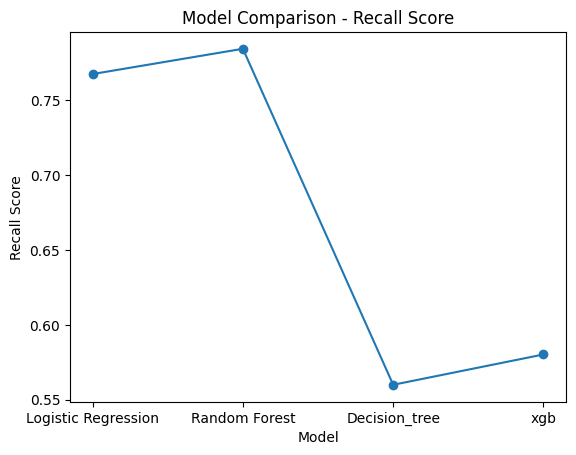

In [146]:
models = ['Logistic Regression', 'Random Forest','Decision_tree','xgb']
recall_scores = [log_recall ,rf_recall,dt_recall,xgb_recall]
plt.figure()
plt.plot(models, recall_scores, marker='o')
plt.title("Model Comparison - Recall Score")
plt.xlabel("Model")
plt.ylabel("Recall Score")
plt.show()

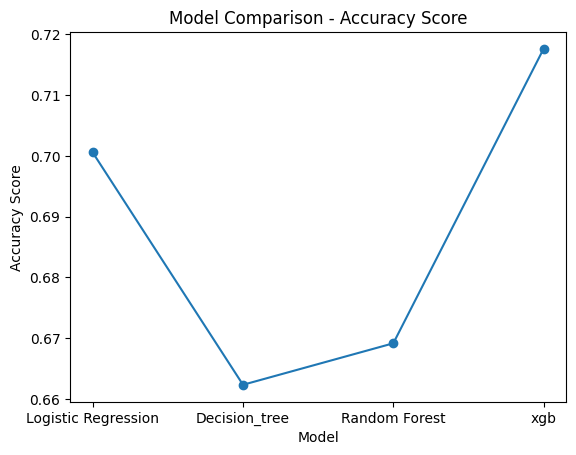

In [147]:
models = ['Logistic Regression','Decision_tree', 'Random Forest','xgb']
recall_scores = [log_accuracy ,dt_accuracy,rf_accuracy,xgb_accuracy]
import matplotlib.pyplot as plt

plt.figure()
plt.plot(models, recall_scores, marker='o')

plt.title("Model Comparison - Accuracy Score")
plt.xlabel("Model")
plt.ylabel("Accuracy Score")
plt.show()

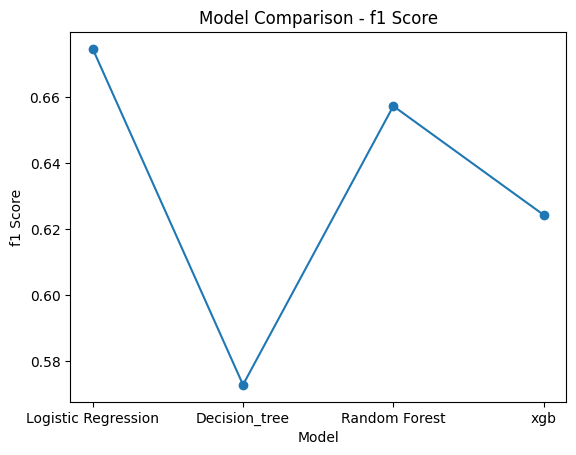

In [148]:
models = ['Logistic Regression','Decision_tree', 'Random Forest','xgb']
f1_scores = [log_f1 ,dt_f1,rf_f1,xgb_f1]
import matplotlib.pyplot as plt

plt.figure()
plt.plot(models, f1_scores, marker='o')

plt.title("Model Comparison - f1 Score")
plt.xlabel("Model")
plt.ylabel("f1 Score")
plt.show()

#### Model Selection Report 
* Now  we try to find best model for this dataset  based on diffirent metrics.

  * **Recall Comparison**
    * From the graph:
      * Random Forest        - Highest recall (~78%)
      * Logistic Regression  - ~77%
      *  XGBoost             - ~58%
      * Decision Tree        - ~57%

It Means:
**Random Forest and Logistic are much better at catching high-potential leads.**

**Decision Tree and XGBoost miss many good leads.**

**`Since your goal is to identify high-quality leads, recall is very important.`**

  * **Based only on recall -  Random Forest is best**

---
  * **Accuracy Comparison**
     From the graph:
     * XGBoost - ~72% (highest accuracy)
     * Logistic Regression - ~70%
     * Random Forest / Decision Tree - ~67%
What This Means:
     **XGBoost predicts overall classes slightly better.But accuracy is not your main prioritybecause your data is slightly imbalanced.**

**Accuracy can be misleading.**

---
  * **F1 Score Comparison (Balance Between Precision & Recall)**
    * From the graph:
      * Logistic Regression - ~67%
      * Random Forest - ~66%
      * XGBoost - ~62%
      * Decision Tree → ~58%
What This Means:
**Logistic Regression has the best balance between precision and recall.It is the most stable model overall.**

---
Lets compare properly :
| Model         | Accuracy | Recall | F1  | Overall                 |
| ------------- | -------- | ------ | --- | ----------------------- |
| Logistic      | 70%      | 77%    | 67% |  Balanced              |
| Random Forest | 67%      | 78%    | 66% |  Highest Recall        |
| Decision Tree | 66%      | 57%    | 58% |  Weak                  |
| XGBoost       | 72%      | 58%    | 62% | Balanced but Low Recall |


Final Conclusion (Simple)

If your goal is:
 * Capture Maximum High-Potential Leads
   * Choose Random Forest
 * Want Balanced & Stable Model
   * Choose Logistic Regression
 * Want Highest Accuracy Only
   * Choose XGBoost

---

#### Model Selection from Bussiness perspective
Since our project goal is :
  * Improve Sales Effectiveness by identifying high-quality leads
  * The most important metric is Recall for High_potential.
  * Therefore:Random Forest is your best final model
  * It catches the most valuable customers.
    
---


### **Final model selection perspective**

**Among all evaluated models, `Random Forest achieved the highest recall for high-potential leads while maintaining competitive overall performance, making it the most suitable model for improving sales effectiveness.`**

---

## Model  dumping using joblib library

In [151]:
joblib.dump(rf_grid.best_estimator_, "lead_quality_model.pkl")
print("Model successfully dump in to pkl file ready to use for production")

Model successfully dump in to pkl file ready to use for production


---
---